# SVM Implementation with Linear & RBF Kernels using NumPy (from scratch) and Scikit-learn


### Learning Objectives
- Build intuition for SVM margins and support vectors.
- Implement a simple linear soft-margin SVM with NumPy from scratch.
- Train linear and RBF SVMs using scikit-learn.
- Tune hyperparameters (`C`, `gamma`) and compare model behavior.
- Evaluate SVMs on a real-world binary classification dataset.

### Prerequisites
- NumPy arrays and vectorized operations
- Matplotlib / Seaborn plotting
- scikit-learn basics
- train-test split and feature scaling

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
np.random.seed(42)
print("Imports loaded.")

Imports loaded.


## 2) Brief Theory Recap

- **Hard margin SVM**: assumes perfect linear separability.
- **Soft margin SVM**: allows some margin violations using hinge loss.
- **Support vectors**: critical points that define the decision boundary.
- **Primal objective** (soft margin):

$$\min_{w,b}\;\frac{1}{2}\|w\|^2 + C\sum_i\max(0,1-y_i(w^Tx_i+b))$$

- **Kernel trick** maps data implicitly:
  - Linear: $K(x_i,x_j)=x_i^Tx_j$
  - RBF: $K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$
- Hyperparameters:
  - `C`: regularization vs misclassification trade-off
  - `gamma`: locality/complexity of RBF boundary

## 3) Guided Example – Simple Synthetic Dataset (`make_moons`)

Dataset: `make_moons(n_samples=300, noise=0.15, random_state=42)`

In [2]:
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
print("X shape:", X.shape)
print("Class counts:", np.bincount(y))

X shape: (300, 2)
Class counts: [150 150]


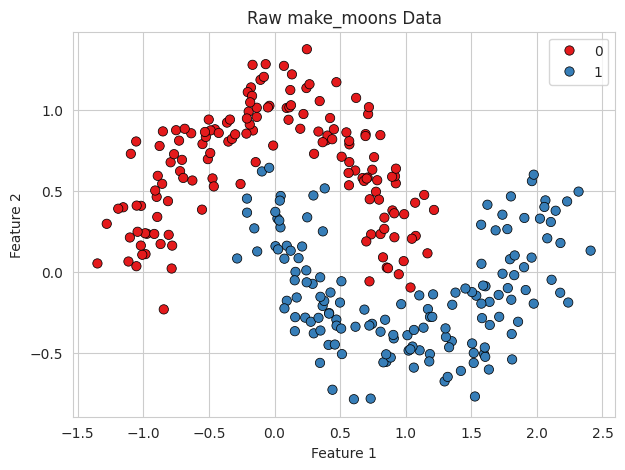

In [3]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=45, edgecolor="k")
plt.title("Raw make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [4]:
def plot_decision_boundary(model, X, y, ax=None, title="Decision Boundary", plot_support=True):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=35, edgecolor="k", ax=ax, legend=False)
    if plot_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

### 3A) NumPy from-scratch part (Linear SVM only) — FIRST

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

Train shape: (225, 2) Test shape: (75, 2)


In [6]:
class LinearSVMFromScratch:
    """
    Soft-margin linear SVM trained with subgradient descent.
    Objective: 0.5 * ||w||^2 + C * mean(max(0, 1 - y*(w^T x + b)))
    """
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=250, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def _objective(self, X, y_signed):
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y_signed * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                margin_ok = y_signed[i] * (np.dot(x_i, self.w) + self.b) >= 1
                if margin_ok:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            self.loss_history.append(self._objective(X, y_signed))

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

In [7]:
svm_np = LinearSVMFromScratch(C=1.0, learning_rate=0.001, n_iters=250)
svm_np.fit(X_train_scaled, y_train)

pred_np = svm_np.predict(X_test_scaled)
acc_np = accuracy_score(y_test, pred_np)
print(f"NumPy Linear SVM accuracy: {acc_np:.4f}")

lin_svc = LinearSVC(C=1.0, random_state=42, max_iter=5000)
lin_svc.fit(X_train_scaled, y_train)
pred_linsvc = lin_svc.predict(X_test_scaled)
acc_linsvc = accuracy_score(y_test, pred_linsvc)
print(f"sklearn LinearSVC accuracy: {acc_linsvc:.4f}")

NumPy Linear SVM accuracy: 0.8267
sklearn LinearSVC accuracy: 0.8533


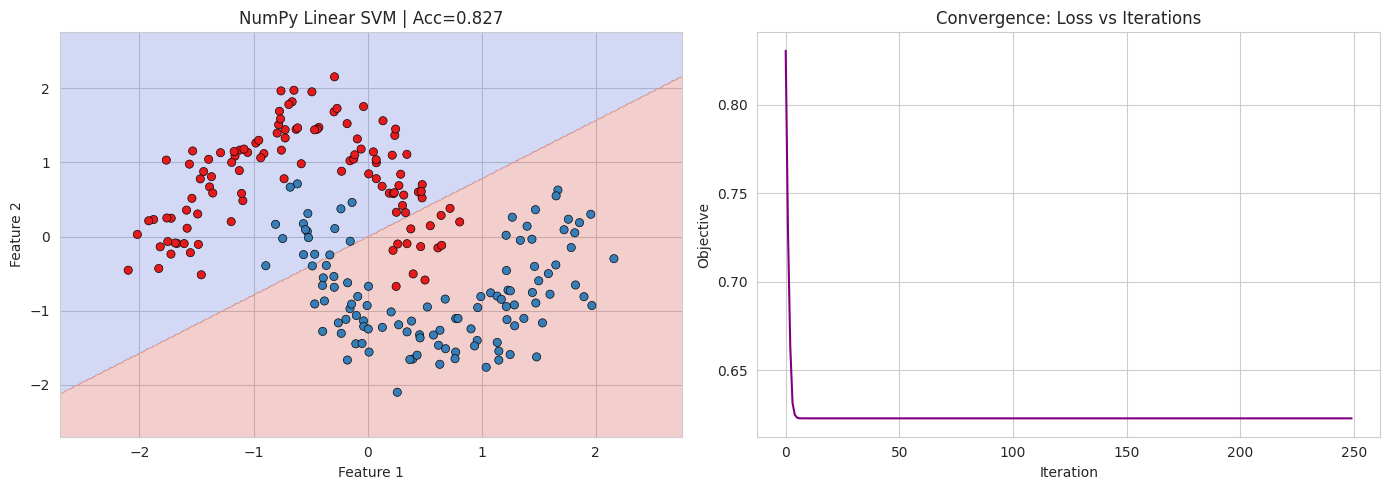

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_np, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM | Acc={acc_np:.3f}", plot_support=False)
axes[1].plot(svm_np.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

### 3B) Scikit-learn part (Linear + RBF) — SECOND

In [9]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

acc_linear = accuracy_score(y_test, svm_linear.predict(X_test_scaled))
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))

print(f"Linear SVC accuracy: {acc_linear:.4f}")
print(f"RBF SVC accuracy:    {acc_rbf:.4f}")

Linear SVC accuracy: 0.8400
RBF SVC accuracy:    0.9733


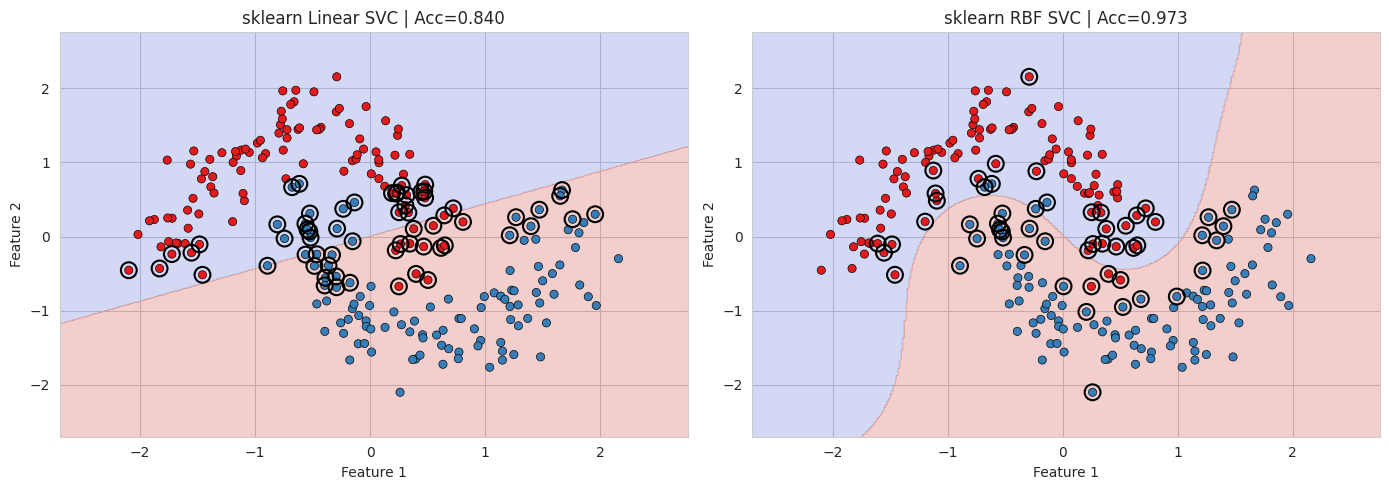

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_linear, X_train_scaled, y_train, ax=axes[0], title=f"sklearn Linear SVC | Acc={acc_linear:.3f}")
plot_decision_boundary(svm_rbf, X_train_scaled, y_train, ax=axes[1], title=f"sklearn RBF SVC | Acc={acc_rbf:.3f}")
plt.tight_layout()
plt.show()

**Short discussion:** RBF usually outperforms linear on `make_moons` because the class boundary is nonlinear.

## 4) Student Tasks / Assignment (Total = 100%)

### 50% – NumPy Implementation (from scratch)

**Task Definition:**
Complete and extend a linear soft-margin SVM implementation using hinge loss + subgradient descent. Analyze convergence and parameter effects.

**TODO (below):**
- Complete class methods.
- Run at least 3 (`C`, `learning_rate`) combinations.
- Plot loss vs iterations for each setting.
- Explain hinge-loss gradient and max-margin intuition in comments/markdown.
- Bonus: add simple linear kernel function.

**Hints:**
- Convert labels to `{-1, +1}` for hinge-loss formula.
- Use condition `y_i*(w.x_i + b) >= 1` to choose update case.
- Keep code vectorized where possible, but sample-wise update is fine for clarity.
- Track loss each epoch in `loss_history`.

NumPy Linear SVM accuracy 1: 0.4800
NumPy Linear SVM accuracy 2: 0.8400
NumPy Linear SVM accuracy 3: 0.4933



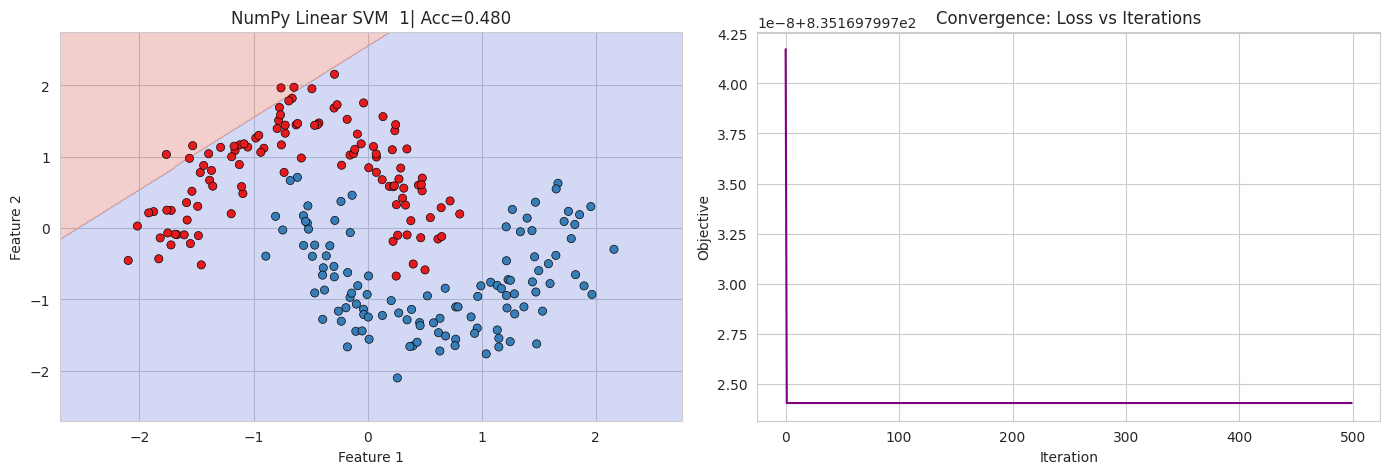

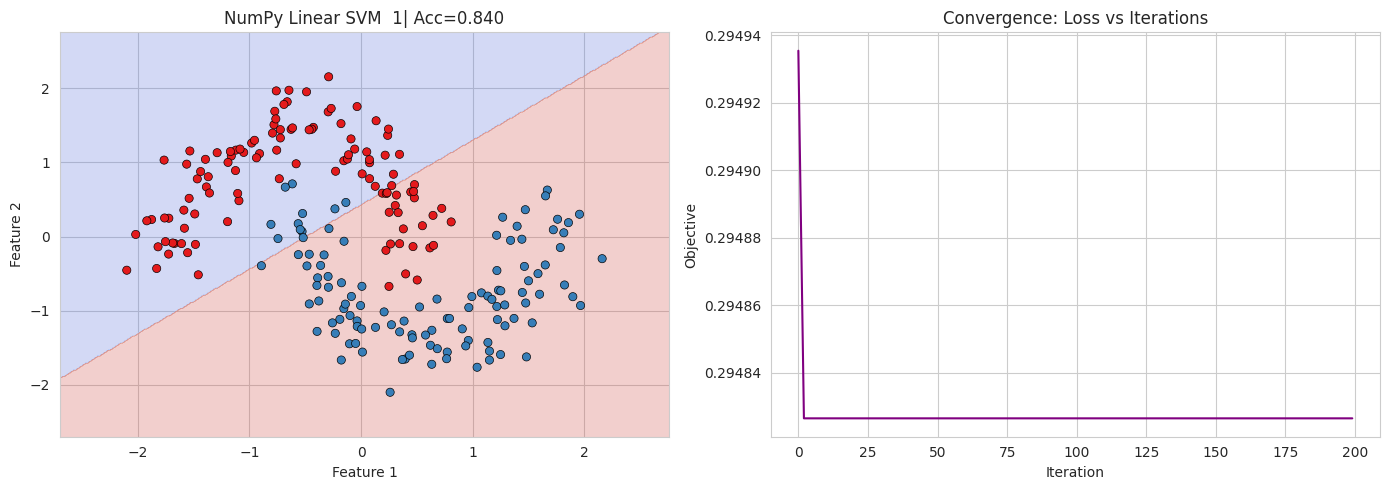

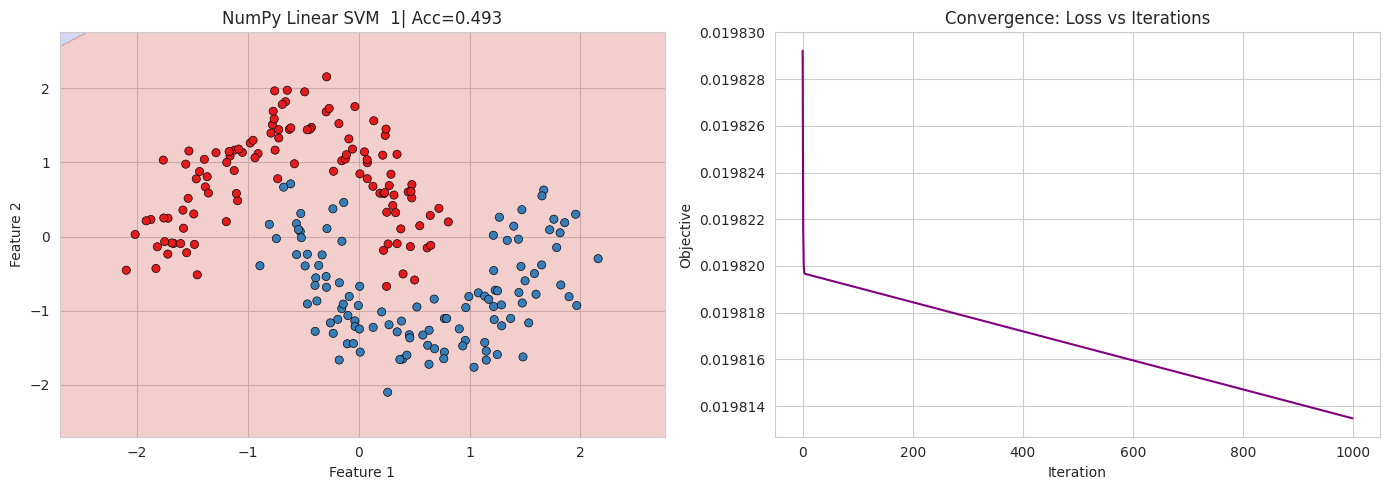

In [27]:
# TODO: Student code here
# 50% NumPy Task

class LinearSVMStudent:
    """
    Soft-margin linear SVM trained with subgradient descent.
    Objective: 0.5 * ||w||^2 + C * mean(max(0, 1 - y*(w^T x + b)))
    """
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def linear_kernel(self, X1, X2):
        return np.dot(X1, X2.T)

    def _objective(self, X, y_signed):
        # Hinge Loss: max(0, 1 - y * (wTx + b))
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y_signed * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1) # Convert labels to -1, 1
        n_samples, n_features = X.shape

        # Initialize weights and bias
        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                margin_condition = y_signed[i] * (np.dot(x_i, self.w) + self.b)
                if margin_condition >= 1:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            self.loss_history.append(self._objective(X, y_signed))

        return self

    def decision_function(self, X):
        # TODO: Student code here
        return X @ self.w + self.b

    def predict(self, X):
        # TODO: Student code here
        return (self.decision_function(X) >= 0).astype(int)

# TODO: Student code here
# Train with 3+ hyperparameter settings, compare accuracy, and plot convergence.
svm_ex1 = LinearSVMStudent(C=100, learning_rate=0.1, n_iters=500)
svm_ex1.fit(X_train_scaled, y_train)

pred_ex1 = svm_ex1.predict(X_test_scaled)
acc_ex1 = accuracy_score(y_test, pred_ex1)

#lr = 0.01 0.03 0.09
#c = 0.01 0.0001 1 10 100 1000
svm_ex2 = LinearSVMStudent(C=0.35, learning_rate=0.1, n_iters=200)
svm_ex2.fit(X_train_scaled, y_train)

pred_ex2 = svm_ex2.predict(X_test_scaled)
acc_ex2 = accuracy_score(y_test, pred_ex2)

svm_ex3 = LinearSVMStudent(C=0.02, learning_rate=0.0035, n_iters=1000)
svm_ex3.fit(X_train_scaled, y_train)

pred_ex3 = svm_ex3.predict(X_test_scaled)
acc_ex3 = accuracy_score(y_test, pred_ex3)
print(f"NumPy Linear SVM accuracy 1: {acc_ex1:.4f}")
print(f"NumPy Linear SVM accuracy 2: {acc_ex2:.4f}")
print(f"NumPy Linear SVM accuracy 3: {acc_ex3:.4f}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_ex1, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM  1| Acc={acc_ex1:.3f}", plot_support=False)
axes[1].plot(svm_ex1.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_ex2, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM  1| Acc={acc_ex2:.3f}", plot_support=False)
axes[1].plot(svm_ex2.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_ex3, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM  1| Acc={acc_ex3:.3f}", plot_support=False)
axes[1].plot(svm_ex3.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

### 30% – Scikit-learn Advanced Usage

**Task Definition:**
Use production-style sklearn workflow with `Pipeline`, scaling, and hyperparameter search. Compare 4 models fairly.

**TODO (below):**
- Build `Pipeline(StandardScaler + SVC)` for linear and RBF.
- Tune RBF with `GridSearchCV` over `C` and `gamma`.
- Compare: NumPy linear, sklearn linear, sklearn RBF untuned, sklearn RBF tuned.
- Report accuracy and plot decision boundaries.

**Hints:**
- Use param names with pipeline prefix (e.g., `svc__C`, `svc__gamma`).
- Start with a small grid, then refine.
- Keep `random_state` fixed for reproducibility.
- Use one summary DataFrame for clean comparison.

Pipeline Linear SVC accuracy: 0.8400
Pipeline RBF SVC (untuned) accuracy: 0.9733

Best RBF SVC (tuned) parameters: {'svc__C': 10, 'svc__gamma': 1}
Pipeline RBF SVC (tuned) accuracy: 0.9733


,Model,Accuracy
3,sklearn RBF SVC (tuned),0.973333
2,sklearn RBF SVC (untuned),0.973333
1,sklearn Linear SVC (untuned),0.840000
0,NumPy Linear SVM (from scratch),0.826667


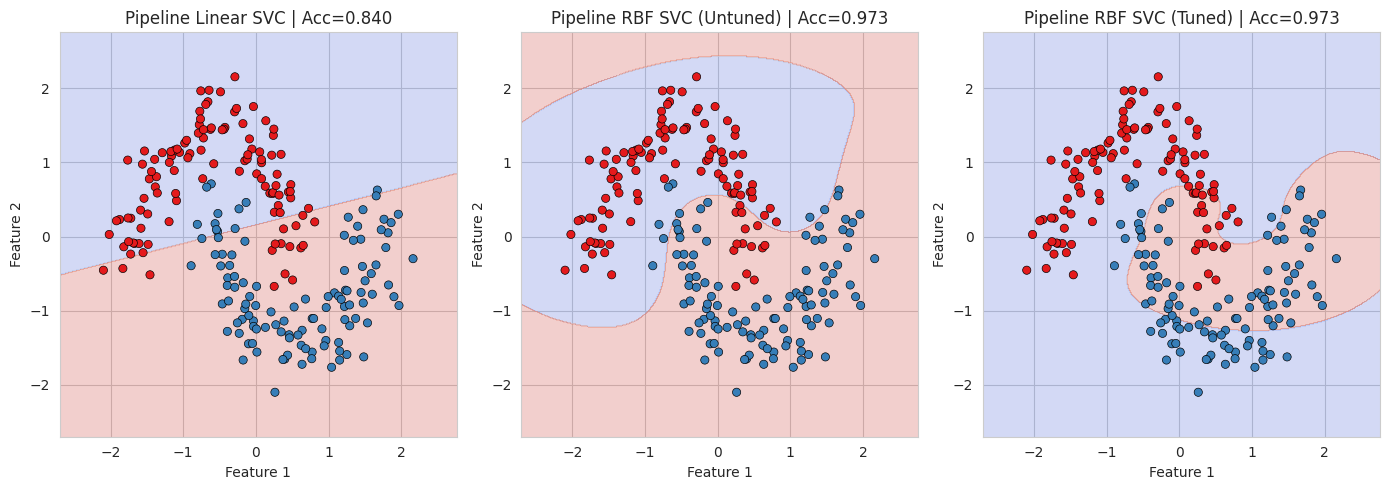

In [20]:
# TODO: Student code here
# 30% sklearn Task

# 1) Build pipelines for linear and RBF SVM
pipeline_linear_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', random_state=42))
])

pipeline_rbf_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
])

# 2) Fit untuned models
pipeline_linear_svc.fit(X_train, y_train)
pipeline_rbf_svc.fit(X_train, y_train)

# Predict and evaluate untuned models
pred_linear_pipeline = pipeline_linear_svc.predict(X_test)
acc_linear_pipeline = accuracy_score(y_test, pred_linear_pipeline)

pred_rbf_pipeline_untuned = pipeline_rbf_svc.predict(X_test)
acc_rbf_pipeline_untuned = accuracy_score(y_test, pred_rbf_pipeline_untuned)

print(f"Pipeline Linear SVC accuracy: {acc_linear_pipeline:.4f}")
print(f"Pipeline RBF SVC (untuned) accuracy: {acc_rbf_pipeline_untuned:.4f}")

# 3) Tune RBF on C and gamma
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.1, 1]
}

grid_search_rbf = GridSearchCV(pipeline_rbf_svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rbf.fit(X_train, y_train)

best_rbf_svc_pipeline = grid_search_rbf.best_estimator_

pred_rbf_pipeline_tuned = best_rbf_svc_pipeline.predict(X_test)
acc_rbf_pipeline_tuned = accuracy_score(y_test, pred_rbf_pipeline_tuned)

print(f"\nBest RBF SVC (tuned) parameters: {grid_search_rbf.best_params_}")
print(f"Pipeline RBF SVC (tuned) accuracy: {acc_rbf_pipeline_tuned:.4f}")

# 4) Compare all 4 models in a DataFrame
results_df = pd.DataFrame({
    'Model': [
        'NumPy Linear SVM (from scratch)',
        'sklearn Linear SVC (untuned)',
        'sklearn RBF SVC (untuned)',
        'sklearn RBF SVC (tuned)'
    ],
    'Accuracy': [
        acc_np, # From previous NumPy task
        acc_linear_pipeline,
        acc_rbf_pipeline_untuned,
        acc_rbf_pipeline_tuned
    ]
})

display(results_df.sort_values(by='Accuracy', ascending=False))

# 5) Plot decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_decision_boundary(pipeline_linear_svc, X_train_scaled, y_train, ax=axes[0], title=f"Pipeline Linear SVC | Acc={acc_linear_pipeline:.3f}")
plot_decision_boundary(pipeline_rbf_svc, X_train_scaled, y_train, ax=axes[1], title=f"Pipeline RBF SVC (Untuned) | Acc={acc_rbf_pipeline_untuned:.3f}")
plot_decision_boundary(best_rbf_svc_pipeline, X_train_scaled, y_train, ax=axes[2], title=f"Pipeline RBF SVC (Tuned) | Acc={acc_rbf_pipeline_tuned:.3f}")
plt.tight_layout()
plt.show()

### 20% – Real-World Dataset Application (`load_breast_cancer`)

**Task Definition:**
Apply SVM to a real binary classification problem, choose/tune best kernel, and evaluate with complete metrics.

**TODO (below):**
- Load and split data (80/20, stratified).
- Scale features.
- Build + tune candidate SVM models.
- Evaluate: accuracy, precision, recall, F1, confusion matrix, report.
- Plot decision boundary using first two PCA components (or discuss feature behavior).
- Write short analysis on kernel and hyperparameter impact.

**Hints:**
- Use `Pipeline` to avoid leakage.
- Keep one untouched test set for final evaluation.
- If PCA plot looks simplified, note that it is a 2D projection.
- Mention overfitting signs (very high train vs lower test performance).

Dataset shape: (569, 30)
Target names: ['malignant' 'benign']
Train shape: (455, 30), Test shape: (114, 30)

Best Linear SVM parameters: {'svc__C': 0.1}
Best RBF SVM parameters: {'svc__C': 10, 'svc__gamma': 0.01}


,Model,Accuracy,Precision,Recall,F1-score
0,Linear SVM (Breast Cancer),0.982456,0.986111,0.986111,0.986111
1,RBF SVM (Breast Cancer),0.982456,0.986111,0.986111,0.986111


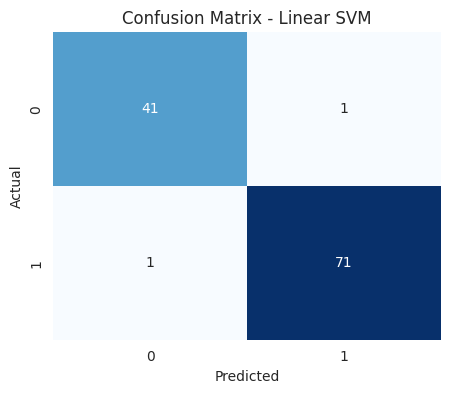

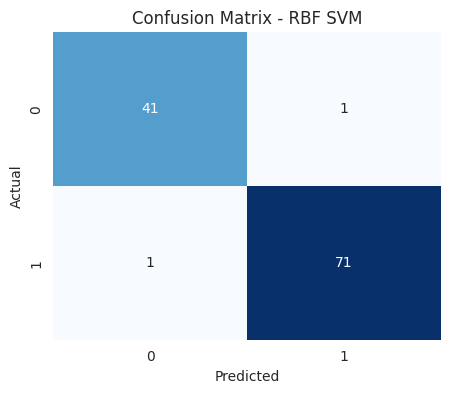


--- Classification Report (Linear SVM) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- Classification Report (RBF SVM) ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



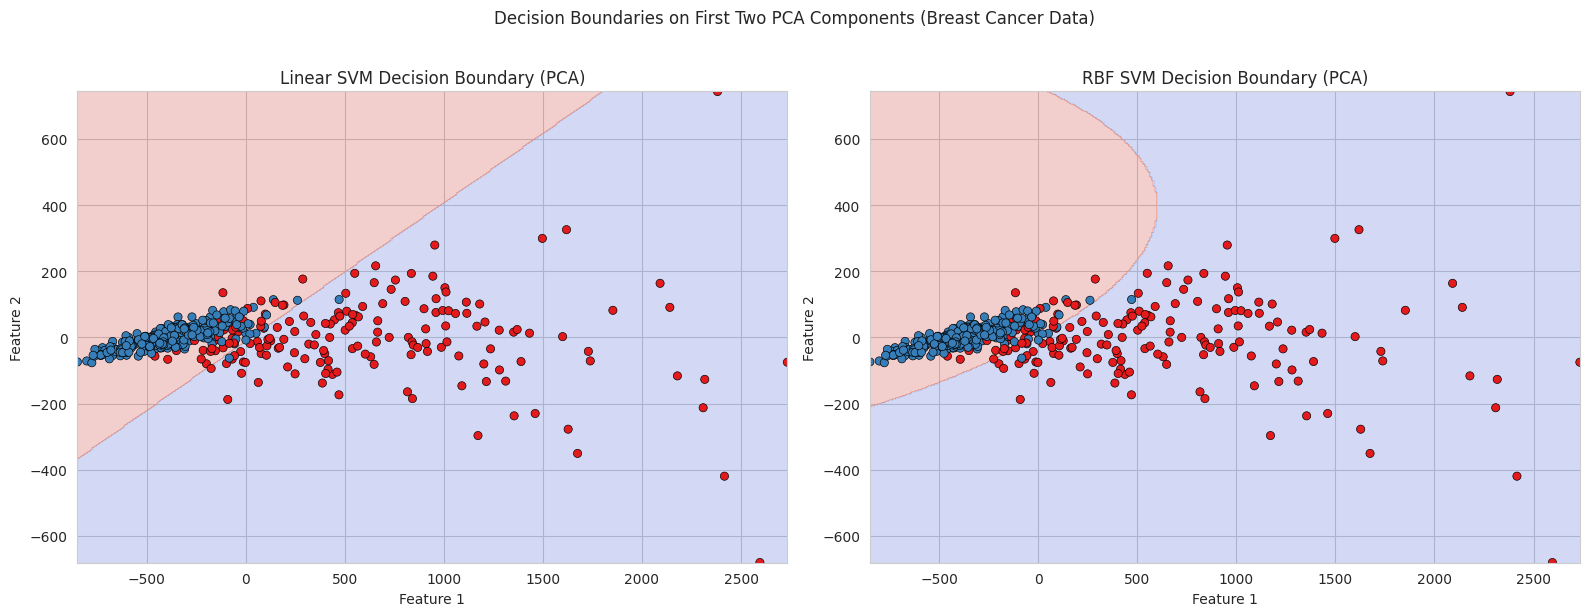

In [19]:
# TODO: Student code here
# 20% Real-world task

bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target

print("Dataset shape:", X_bc.shape)
print("Target names:", bc.target_names)

# Split data (80/20, stratified)
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

print(f"Train shape: {X_train_bc.shape}, Test shape: {X_test_bc.shape}")

# Build Pipelines for Linear and RBF SVM
pipeline_bc_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', random_state=42))
])

pipeline_bc_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
])

# Define parameter grids for GridSearchCV
param_grid_linear = {
    'svc__C': [0.1, 1, 10]
}

param_grid_rbf = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto', 0.01, 0.1]
}

# Tune Linear SVM
grid_search_bc_linear = GridSearchCV(pipeline_bc_linear, param_grid_linear, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_bc_linear.fit(X_train_bc, y_train_bc)

best_linear_bc_model = grid_search_bc_linear.best_estimator_

# Tune RBF SVM
grid_search_bc_rbf = GridSearchCV(pipeline_bc_rbf, param_grid_rbf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_bc_rbf.fit(X_train_bc, y_train_bc)

best_rbf_bc_model = grid_search_bc_rbf.best_estimator_

print(f"\nBest Linear SVM parameters: {grid_search_bc_linear.best_params_}")
print(f"Best RBF SVM parameters: {grid_search_bc_rbf.best_params_}")

# Evaluate Best Models
pred_linear_bc = best_linear_bc_model.predict(X_test_bc)
pred_rbf_bc = best_rbf_bc_model.predict(X_test_bc)

# Create metrics dataframes
metrics_linear_df = metrics_table(y_test_bc, pred_linear_bc, "Linear SVM (Breast Cancer)")
metrics_rbf_df = metrics_table(y_test_bc, pred_rbf_bc, "RBF SVM (Breast Cancer)")

bc_results_df = pd.concat([metrics_linear_df, metrics_rbf_df], ignore_index=True)
display(bc_results_df.sort_values(by='Accuracy', ascending=False))

# Plot Confusion Matrices
plot_confusion(y_test_bc, pred_linear_bc, title="Confusion Matrix - Linear SVM")
plot_confusion(y_test_bc, pred_rbf_bc, title="Confusion Matrix - RBF SVM")

# Classification Reports
print("\n--- Classification Report (Linear SVM) ---")
print(classification_report(y_test_bc, pred_linear_bc))
print("\n--- Classification Report (RBF SVM) ---")
print(classification_report(y_test_bc, pred_rbf_bc))

# PCA for Decision Boundary Visualization (using first 2 components)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_bc)
X_test_pca = pca.transform(X_test_bc)

# Retrain models on PCA-transformed data for plotting (this is illustrative, not for final evaluation)
pipeline_bc_linear_pca = Pipeline([
    ('scaler', StandardScaler()), # Scaler is still important for PCA
    ('svc', SVC(kernel='linear', C=grid_search_bc_linear.best_params_['svc__C'], random_state=42))
])
pipeline_bc_rbf_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=grid_search_bc_rbf.best_params_['svc__C'], gamma=grid_search_bc_rbf.best_params_['svc__gamma'], random_state=42))
])

pipeline_bc_linear_pca.fit(X_train_pca, y_train_bc)
pipeline_bc_rbf_pca.fit(X_train_pca, y_train_bc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_decision_boundary(pipeline_bc_linear_pca, X_train_pca, y_train_bc, ax=axes[0], title="Linear SVM Decision Boundary (PCA)")
plot_decision_boundary(pipeline_bc_rbf_pca, X_train_pca, y_train_bc, ax=axes[1], title="RBF SVM Decision Boundary (PCA)")
plt.suptitle("Decision Boundaries on First Two PCA Components (Breast Cancer Data)", y=1.02)
plt.tight_layout()
plt.show()


## 5) Additional Notebook Sections

In [18]:
def metrics_table(y_true, y_pred, model_name="Model"):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-score": [f1_score(y_true, y_pred)]
    })

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("Helper functions ready.")

Helper functions ready.


### Reflection Questions
1. Why does RBF outperform linear on moons data?
2. How does increasing `C` affect margin and errors?
3. How does `gamma` control complexity in RBF?
4. Why is scaling essential for SVM?
5. What did convergence plots reveal in your NumPy model?